In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import time as tm
from time import time
import fitsio
import pandas as pd
from galpy.potential import MWPotential2014, vcirc, evaluateRforces
from galpy.orbit import Orbit
from scipy.stats import gaussian_kde, ks_2samp, kstest
from hyppo.ksample import Energy
import corner
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

from astroquery.gaia import Gaia
from astropy.table import Table
from astropy.table import Table, vstack
from glob import glob
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.linear_model import LinearRegression
import os
from datetime import datetime
from matplotlib.ticker import AutoLocator
import re

Please note the archive will not be accessible on 29 July from 11 to 13 CEST, for maintenance purposes. Apologies for the inconveniences.


In [2]:
# Setup and helper functions moved to external module
from plots_for_ASA_cell2 import *

# If you change the external module and want live reload during development, uncomment:
# %load_ext autoreload
# %autoreload 2

In [3]:
with fitsio.FITS(galah_Gaia_fits) as hdul1:
    data_1 = hdul1[1].read()
galah_Gaia_raw = pd.DataFrame(data_1)
galah_Gaia_raw = ensure_native_endian(galah_Gaia_raw)

In [4]:
galah_Gaia = galah_Gaia_raw[(galah_Gaia_raw['snr_px_ccd3'] > 30)       # Kushniruk 2026 also has cuts in log g and temp. I wonder if I should as well
                        & (galah_Gaia_raw['flag_sp'] == 0)
                        & (galah_Gaia_raw['flag_fe_h'] == 0)
                        & (galah_Gaia_raw['e_fe_h'] < 0.2)
                        & (galah_Gaia_raw['flag_sp_fit'] == 0)
                        & (galah_Gaia_raw['flag_red'] == 0)
                        & (galah_Gaia_raw['ruwe'] < 1.4)
                        & (galah_Gaia_raw['logg'] < 3.5)
                        & (galah_Gaia_raw['teff'] > 4000)
                        & (galah_Gaia_raw['teff'] < 6500)
                        # & (galah_Gaia_raw['flag_mg_fe'] == 0)
                        # & (galah_Gaia_raw['flag_na_fe'] == 0)
                        # & (galah_Gaia_raw['flag_cu_fe'] == 0)
                        & (galah_Gaia_raw['fe_h'] < -0.75)
                        # & (galah_Gaia_raw['fe_h'] < -0.9)
                        # & (galah_Gaia_raw['ti_fe'] > 0.25)
                        & (galah_Gaia_raw['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main',
                                                               'k2_hermes', 'galah_phase2', 'tess_hermes'
                                                               ]))
    ]

In [5]:
NGC3201_galah = pd.merge( galah_Gaia, Vmans_NGC3201_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')
NGC5139_galah = pd.merge( galah_Gaia, Vmans_NGC5139_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')
NGC1851_galah = pd.merge( galah_Gaia, Vmans_NGC1851_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')

galah_Kushniruk_GSE = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-35)**2) / (17.5**2)) + (((galah_Gaia['jphi'] + 130)**2) / (250**2)) < 1)
                                 & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                 & (galah_Gaia_raw['flag_mg_fe'] == 0)
                                 & (galah_Gaia_raw['flag_na_fe'] == 0)
                                 & (galah_Gaia_raw['flag_cu_fe'] == 0)
                                 & ((galah_Gaia_raw['mg_fe'] - galah_Gaia_raw['cu_fe']) - ((1.06923) * galah_Gaia_raw['na_fe']) > 0.40150)
                                 ]

# Kushniruk et al . 2026 https://doi.org/10.1051/0004-6361/202451201
galah_Kushniruk_Thamnos1 = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])- 13.5)**2) / (4.0**2)) + (((galah_Gaia['jphi'] + 600)**2) / (350**2)) < 1)
                                        & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                        & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                        # & (galah_Gaia['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main']))
                                      ]

galah_Kushniruk_Thamnos2 = galah_Gaia[(((np.sqrt(galah_Gaia['jr'])-8.6)**2) / (3.5**2)) + (((galah_Gaia['jphi'] + 1184)**2) / (175**2)) < 1
                                        & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                        & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                        # & (galah_Gaia['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main']))
                                      ]

# Feuillet et al. 2021 https://doi.org/10.1093/mnras/stab2614
galah_Gaia_GSE = galah_Gaia[GSE_cuts_Diane_2021(galah_Gaia)
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                            # & (galah_Gaia['fe_h'] < -0.8)
                            ]

galah_Gaia_Sequoia = galah_Gaia[Sequoia_cuts_Diane_2021(galah_Gaia)
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                            # & (galah_Gaia['fe_h'] < -0.8)
                            ]

galah_Gaia_Halo = galah_Gaia[(np.sqrt((galah_Gaia['vphi']-230)**2 + (galah_Gaia['vr'])**2 + (galah_Gaia['vz'])**2) > 230) # Koppelman et al. 2019  https://doi.org/10.1051/0004-6361/201936738
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id'])) 
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id'])) 
                            # & (galah_Gaia_raw['ti_fe'] > 0.25)
                             ]

/tmp/ipykernel_4029/3381787813.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  galah_Kushniruk_GSE = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-35)**2) / (17.5**2)) + (((galah_Gaia['jphi'] + 130)**2) / (250**2)) < 1)



In [6]:
element_list_full_galah = ["h", "fe", "n", "o", "na", "mg", "al", "si", "k", "ca", "sc" ,"ti" "v", "cr" ,"mn", "co", "ni", "cu", "zn", "rb", "sr", "y", "zr", "mo", "ru", "ba", "la", "ce", "nd", "sm", "eu"]# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.
element_list_partial_small_galah_1 = [ 'fe', 'ca', 'ti', 'na', 'mn', 'cu','mg']
element_list_partial_small_galah_2 = [ 'fe', 'ca', 'na', 'mn', 'cu','mg', 'nd']
element_list_partial_small_galah_3 = [ 'cu', 'ca', 'mn', 'ni','v','na', 'nd']
element_list_partial_small_galah_4 = [ 'cu', 'ca', 'mn', 'ti','v','na', 'nd']
element_list_partial_small_galah_5 = [ 'cu', 'ca', 'mn', 'ti','ba','na', 'nd']
element_list_partial_small_galah_6 = [ 'cu', 'ca', 'mn', 'ti', 'v', 'ba','na', 'nd']
element_list_partial_small_galah_7 = [ 'fe', 'cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_2 = ['cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_3 = ['fe', 'v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_7_4 = ['fe', 'si', 'nd', 'na', 'mg', 'k', 'ca', 'sc', 'ti', 'v', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba']
element_list_partial_small_galah_7_5 = ['v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_7_6 = ['v', 'k', 'na', 'mg', 'si', 'ca', 'sc', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_8 = [ 'ca', 'mn', 'y', 'v', 'na', 'nd', 'cr', 'sc']
element_list_partial_small_galah_9 = [ 'cu', 'ca', 'mn', 'ti', 'sc', 'v', 'na', 'nd']
element_list_partial_small_galah_10 = ['fe', 'v', 'sc', 'si', 'ca', 'mn', 'na', 'nd']
element_list_partial_small_galah_12 = ['ca', 'sc', 'na', 'mg', 'si', 'k', 'ti', 'v', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_11 = ['y', 'ba', 'nd', 'eu']


elements_in_Pradosh_Galah_1 = ['ca', 'ti', 'ni','zr', 'ce', 'nd']
elements_in_Pradosh_Galah_2 = ['ca', 'ti', 'ni', 'nd']

element_list = element_list_partial_small_galah_7_5

# element_list_X_frequ = list(X_frequ['element'])
# element_list = element_list_X_frequ

galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia, element_list)

galah_Gaia_new_ratios = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0] # this ontains a full catalog from galah but now it includes ratios for Ca, Si, Ti, Ni, Zr, Ce, and Nd relative to eachother: Pradosh did recomend taking out
                                                                 # Si, and Ni whitch I can do by changing "element_list_partial_large" to element_list_partial_small
galah_gaia_new_element_ratio_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[1]     # this just lists the new columns ratios so I can more easily call them
galah_gaia_new_element_ratio_errors_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[2] 

galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_GSE, element_list)
galah_Gaia_GSE_new_ratios = galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_GSE, element_list)
galah_Gaia_Kushniruk_GSE_new_ratios = galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Sequoia, element_list)
galah_Gaia_Sequoia_new_ratios = galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC3201_galah, element_list)
# galah_Gaia_NGC3201_new_ratios = galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC5139_galah, element_list)
# galah_Gaia_NGC5139_new_ratios = galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos1, element_list)
# galah_Gaia_Thamnos1_new_ratios = galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos2, element_list)
# galah_Gaia_Thamnos2_new_ratios = galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC1851_galah, element_list)
# galah_Gaia_NGC1851_new_ratios = galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Halo, element_list)
galah_Gaia_Halo_new_ratios = galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist[0]

/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/Jupyter Notebooks/plots_for_ASA_cell2.py:608: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_set_flagged[new_ratio_error_label] = np.sqrt((data_set_flagged[err_col_numerator])**2 + (data_set_flagged[err_col_denominator])**2)

/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/Jupyter Notebooks/plots_for_ASA_cell2.py:607: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_set_flagged[new_ratio_label] = data_set_flagged[col_name_for_numerator] - data_set_flag

In [7]:
print(len(galah_Gaia_Sequoia_new_ratios))
print(len(galah_Gaia_GSE_new_ratios))
print(len(galah_Gaia_Halo_new_ratios))

65
527
2026


In [8]:
''' THESE INCLUDE element_list_partial_small_galah_7_5 = ['v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd'] and 2d '''
''' THAMNOS Stars were removed'''
''' Halo_vs_Sequoia and GSE vs Sequoia'''
''' fe_h < -0.75 '''
''' Galah Main Bright Faint'''
''' This was before I added the score to the algorithm, and but beofre removing combinations that involved and comb 1 and comb 2 had X'''

percent_value = 0.3
keep_num_elm = 4
do_costom_elm_filter = False
ratio_list = galah_gaia_new_element_ratio_list

previos_values_lcation_Halo_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/fits and csv files/KS_Tests/two_by_two_ks_test_main_faint_bright_fe_lessthen_min0.75_H_vs_S_.csv'
previos_values_lcation_Halo_vs_Sequoia_raw  = pd.read_csv(previos_values_lcation_Halo_vs_Sequoia)

previos_values_lcation_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/fits and csv files/KS_Tests/two_by_two_ks_test_main_faint_bright_fe_lessthen_min0.75_G_vs_S_.csv'
previos_values_lcation_GSE_vs_Sequoia_raw  = pd.read_csv(previos_values_lcation_GSE_vs_Sequoia)

In [9]:
''' THESE INCLUDE element_list_partial_small_galah_7_5 = ['v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd'] and 2d '''
''' THAMNOS Stars were removed'''
''' Halo_vs_Sequoia and GSE vs Sequoia'''
''' fe_h < -0.75 '''
''' Galah phase 1, 2 and Hermes'''
''' This was after I added the score to the algorithm, but beofre removing combinations that involved and comb 1 and comb 2 had X'''

percent_value = 0.3
keep_num_elm = 4
do_costom_elm_filter = False
ratio_list = galah_gaia_new_element_ratio_list

previos_values_lcation_Halo_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/fits and csv files/KS_Tests/two_by_two_ks_test_phase_1_2_Hermes_fe_lessthen_min0.75_H_vs_S_.csv'
previos_values_lcation_Halo_vs_Sequoia_raw  = pd.read_csv(previos_values_lcation_Halo_vs_Sequoia)

previos_values_lcation_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/fits and csv files/KS_Tests/two_by_two_ks_test_phase_1_2_Hermes_fe_lessthen_min0.75_G_vs_S_.csv'
previos_values_lcation_GSE_vs_Sequoia_raw  = pd.read_csv(previos_values_lcation_GSE_vs_Sequoia)

In [8]:
''' THESE INCLUDE element_list_partial_small_galah_7_5 = ['v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd'] and 2d '''
''' THAMNOS Stars were removed'''
''' Halo_vs_Sequoia and GSE vs Sequoia'''
''' fe_h < -0.75 '''
''' Galah phase 1, 2 and Hermes'''
''' This was after I added the score to the algorithm'''

percent_value = 0.3
keep_num_elm = 4
do_costom_elm_filter = False
ratio_list = galah_gaia_new_element_ratio_list

previos_values_lcation_Halo_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/fits and csv files/KS_Tests/two_by_two_ks_test_no_X_vs_X_phase_1_2_Hermes_fe_lessthen_min0.75_H_vs_S_.csv'
previos_values_lcation_Halo_vs_Sequoia_raw  = pd.read_csv(previos_values_lcation_Halo_vs_Sequoia)

previos_values_lcation_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/fits and csv files/KS_Tests/two_by_two_ks_test_no_X_vs_X_phase_1_2_Hermes_fe_lessthen_min0.75_G_vs_S_.csv'
previos_values_lcation_GSE_vs_Sequoia_raw  = pd.read_csv(previos_values_lcation_GSE_vs_Sequoia)

In [21]:
# df1 = galah_Gaia_Sequoia_new_ratios
df1 = galah_Gaia_GSE_new_ratios
df2 = galah_Gaia_Halo_new_ratios

# chosen_file = previos_values_lcation_GSE_vs_Sequoia_raw
chosen_file = previos_values_lcation_Halo_vs_Sequoia_raw

In [22]:
final_filtered_elm_ratio_list = final_filtered_elm_ratio_list = find_ratio_combination_to_try_for_2d_KS_test(ratio_list, df1, df2, element_list, percent_value = percent_value, keep_num_elm = keep_num_elm, do_costom_elm_filter = False, costom_elm_filter = ['si', 'sc', 'v', 'co', 'nd'])

percent_value =  0.3
len(ratio_1d_ks_test)  136
len(top_percent)  40
v and na_v
v and nd_v
v and cr_v
v and mn_v
v and ca_v
v and y_v
v and ti_v
v and cu_v
v and sc_v
v and k_v
v and mg_v
v and ni_v
v and si_v
v and zn_v
v and ba_v
v and co_v
sc and na_sc
sc and nd_sc
sc and y_sc
sc and cu_sc
sc and si_sc
sc and co_sc
sc and mg_sc
sc and sc_v
sc and ni_sc
sc and ti_sc
sc and zn_sc
sc and cr_sc
sc and mn_sc
sc and ba_sc
sc and ca_sc
sc and k_sc
na and cr_na
na and mn_na
na and nd_na
na and ca_na
na and ni_na
na and ti_na
na and na_sc
na and co_na
na and na_v
na and k_na
na and mg_na
na and si_na
na and zn_na
na and cu_na
na and ba_na
na and y_na
mg and mg_na
mg and nd_mg
mg and cr_mg
mg and mn_mg
mg and ca_mg
mg and y_mg
mg and cu_mg
mg and mg_sc
mg and ti_mg
mg and k_mg
mg and si_mg
mg and mg_v
mg and co_mg
mg and zn_mg
mg and ni_mg
mg and ba_mg
si and nd_si
si and cr_si
si and ca_si
si and si_na
si and mn_si
si and ti_si
si and si_sc
si and k_si
si and ni_si
si and y_si
si and si_mg
s

,element,frequency,score
2,na,13,-762.505766
16,nd,12,-558.540563
8,cr,7,-381.206155
14,y,6,-350.387166
9,mn,6,-321.055713
6,ca,3,-241.923479
12,cu,4,-241.735016
7,ti,4,-237.375235
11,ni,5,-235.335429
4,si,5,-233.325757


auto_elm_filter =  ['na', 'nd', 'cr', 'y']
34


,ratio,p_value,statistic
36,cr_na,8.220777e-43,0.337471
37,mn_na,3.908481e-39,0.322794
134,nd_y,1.139464e-33,0.299542
44,nd_na,1.739857e-32,0.294244
34,ca_na,3.083006e-30,0.283889
39,ni_na,3.901630e-28,0.273832
35,ti_na,1.807805e-27,0.270563
16,na_sc,1.648302e-25,0.260692
38,co_na,8.765579e-20,0.229300
1,na_v,7.380614e-19,0.223795


In [13]:
two_by_two_combinations = make_2_vs_2_combinations(final_filtered_elm_ratio_list, df1, df2, element_list)


len of combined_ratios_list is 378
['ca_v_pl_sc_v', 'ca_v_pl_ti_v', 'ca_v_min_na_sc', 'ca_v_pl_k_na', 'ca_v_min_co_ca', 'ca_v_min_ni_k', 'ca_v_min_cu_ca', 'ca_v_min_cr_k', 'ca_v_pl_k_v', 'ca_v_min_cu_sc', 'ca_v_min_co_k', 'ca_v_min_cu_k', 'ca_v_pl_mg_v', 'ca_v_pl_si_v', 'ca_v_min_co_sc', 'ca_v_min_ni_sc', 'ca_v_min_mn_k', 'ca_v_min_mn_ca', 'ca_v_pl_zn_v', 'ca_v_min_cr_ca', 'ca_v_min_ba_k', 'ca_v_min_ni_ca', 'ca_v_min_ti_sc', 'ca_v_min_ba_sc', 'ca_v_min_cr_sc', 'ca_v_min_ba_ca', 'ca_v_min_mn_sc', 'sc_v_pl_ti_v', 'sc_v_min_na_sc', 'sc_v_pl_k_na', 'sc_v_min_co_ca', 'sc_v_min_ni_k', 'sc_v_min_cu_ca', 'sc_v_min_cr_k', 'sc_v_pl_k_v', 'sc_v_min_cu_sc', 'sc_v_min_co_k', 'sc_v_min_cu_k', 'sc_v_pl_mg_v', 'sc_v_pl_si_v', 'sc_v_min_co_sc', 'sc_v_min_ni_sc', 'sc_v_min_mn_k', 'sc_v_min_mn_ca', 'sc_v_pl_zn_v', 'sc_v_min_cr_ca', 'sc_v_min_ba_k', 'sc_v_min_ni_ca', 'sc_v_min_ti_sc', 'sc_v_min_ba_sc', 'sc_v_min_cr_sc', 'sc_v_min_ba_ca', 'sc_v_min_mn_sc', 'ti_v_min_na_sc', 'ti_v_pl_k_na', 'ti_v_min_co_ca'

In [53]:
Sequoia_w_combined_ratios = make__2_vs_2_combinations_for_further_comparison(final_filtered_elm_ratio_list, galah_Gaia_Sequoia_new_ratios, two_by_two_combinations[3])
GSE_w_combined_ratios = make__2_vs_2_combinations_for_further_comparison(final_filtered_elm_ratio_list, galah_Gaia_GSE_new_ratios, two_by_two_combinations[3])
Halo_w_combined_ratios = make__2_vs_2_combinations_for_further_comparison(final_filtered_elm_ratio_list, galah_Gaia_Halo_new_ratios, two_by_two_combinations[3])
All_Galah_w_combined_ratios = make__2_vs_2_combinations_for_further_comparison(final_filtered_elm_ratio_list, galah_Gaia_new_ratios, two_by_two_combinations[3])

In [54]:
Halo_w_combined_ratios

,sobject_id,tmass_id,gaiadr3_source_id,survey_name,field_id,setup,mjd,ra,dec,flag_sp,...,ti_sc_pl_ba_sc,ti_sc_pl_cr_sc,ti_sc_pl_ba_ca,ti_sc_pl_mn_sc,ba_sc_pl_cr_sc,ba_sc_pl_ba_ca,ba_sc_pl_mn_sc,cr_sc_pl_ba_ca,cr_sc_pl_mn_sc,ba_ca_pl_mn_sc
5769,151009004101166,03254556+1810597,55930202296881280,k2_hermes,6602,allstar,57304.700,51.439835,18.183250,0,...,0.125361,-0.083150,0.006918,-0.344703,-0.276010,-0.185941,-0.537562,-0.394453,-0.746074,-0.656006
10731,150408002901065,08301838+1026373,600068817434968960,k2_hermes,6614,allstar,57120.395,127.576584,10.443722,0,...,0.269828,-0.136463,0.156103,-0.301365,-0.093599,0.198967,-0.258501,-0.207323,-0.664792,-0.372226
13598,160112002301024,08424236+1342390,609143911534194944,k2_hermes,6610,allstar,57399.625,130.676544,13.710861,0,...,0.027314,-0.087547,-0.113808,-0.257449,-0.224378,-0.250639,-0.394280,-0.365499,-0.509141,-0.535402
15667,160109003301383,08301587+1408400,651626184677599744,k2_hermes,6615,allstar,57396.640,127.566124,14.144417,0,...,0.307051,0.081662,0.136626,-0.107261,-0.058417,-0.003452,-0.247340,-0.228841,-0.472729,-0.417764
16126,160331001701267,08265545+1445438,652469926709578624,k2_hermes,6615,allstar,57478.406,126.731087,14.762167,0,...,0.045276,-0.131911,-0.095751,-0.287272,-0.225125,-0.188966,-0.380486,-0.366152,-0.557673,-0.521513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
916286,210524004201173,20512007-1103149,6901934722944726400,galah_main,654,allstar,59358.785,312.833618,-11.054194,0,...,0.340186,-0.028394,0.128174,-0.233442,-0.086684,0.069885,-0.291732,-0.298696,-0.660312,-0.503744
916488,210524004201290,20531743-1001558,6902430057228646656,galah_main,654,allstar,59358.785,313.322723,-10.032166,0,...,0.156741,0.051551,-0.045903,-0.103220,-0.170962,-0.268417,-0.325734,-0.373607,-0.430924,-0.528378
916669,150601004801246,20453056-0913097,6903163495907475328,galah_main,825,allstar,57174.785,311.377319,-9.219389,0,...,0.675998,0.012110,0.381168,-0.181250,0.240099,0.609156,0.046738,-0.054732,-0.617150,-0.248092
916713,150601004801392,20491708-0925257,6903458478557543168,galah_main,825,allstar,57174.785,312.321167,-9.423833,0,...,0.342127,0.073794,0.119277,-0.264924,-0.025013,0.020471,-0.363731,-0.247862,-0.632063,-0.586580


In [55]:
chosen_file.head(15)

,ratio_com_1,ratio_com_2,p_value,statistic
0,na_sc_min_si_v,co_k_pl_cr_ca,1.789438e-10,0.088693
1,na_sc_min_si_v,co_ca_pl_cr_k,1.789438e-10,0.088693
2,co_ca_pl_cr_k,si_v_min_ni_sc,2.869587e-10,0.076532
3,co_k_pl_cr_ca,si_v_min_ni_sc,2.869587e-10,0.076532
4,na_sc_min_si_v,co_ca_pl_mn_k,2.947684e-10,0.091390
5,na_sc_min_si_v,co_k_pl_mn_ca,2.947684e-10,0.091390
6,na_sc_pl_co_ca,si_v_min_mn_k,3.261556e-10,0.091403
7,na_sc_pl_co_ca,cr_k_min_si_v,3.336030e-10,0.087375
8,na_sc_pl_cr_ca,co_k_min_si_v,3.568125e-10,0.085089
9,na_sc_pl_mn_ca,co_k_min_si_v,4.350942e-10,0.089523


In [68]:
row = 0

ratio_combos_1 = chosen_file['ratio_com_1'][row]
ratio_combos_2 = chosen_file['ratio_com_2'][row]

In [69]:
print(ratio_combos_1, ' and ', ratio_combos_2)

na_sc_min_si_v  and  co_k_pl_cr_ca


In [70]:
# ratio_combos_1 = 'co_ca_pl_cr_k'
# ratio_combos_2 = 'na_sc_min_zn_co'

X = Sequoia_w_combined_ratios[[ratio_combos_1, ratio_combos_2]].dropna().to_numpy()
# Y = GSE_w_combined_ratios[[ratio_combos_1, ratio_combos_2]].dropna().to_numpy()
Y = Halo_w_combined_ratios[[ratio_combos_1, ratio_combos_2]].dropna().to_numpy()

statistic, p_value = Energy().test(X, Y)
print(f'statistic: {statistic}, p-value: {p_value},  for {ratio_combos_1} vs {ratio_combos_2}')

statistic: 0.08869293352421169, p-value: 1.7894382103283246e-10,  for na_sc_min_si_v vs co_k_pl_cr_ca


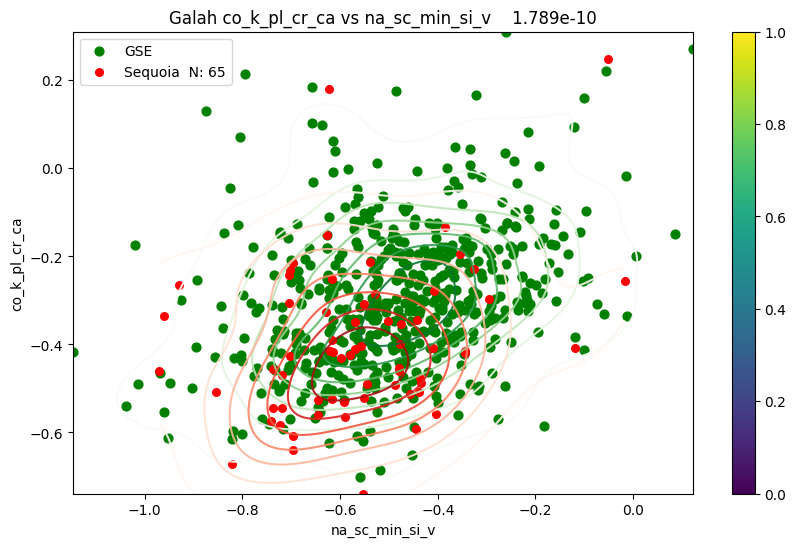

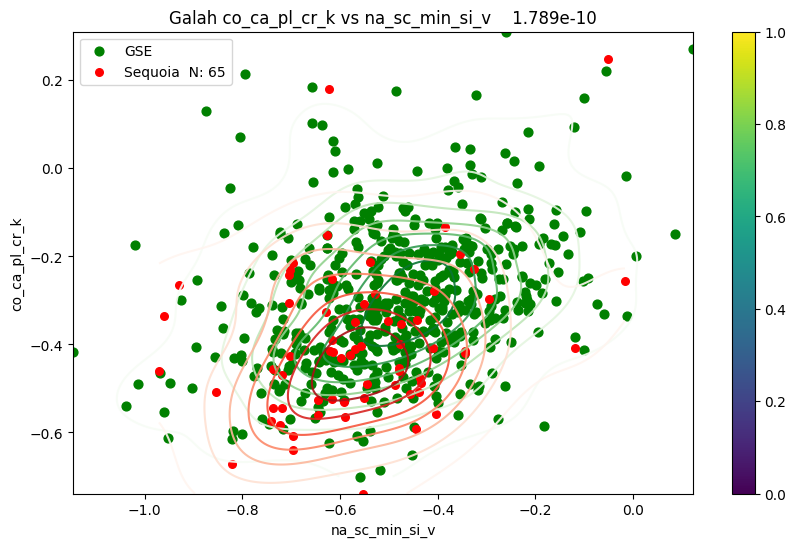

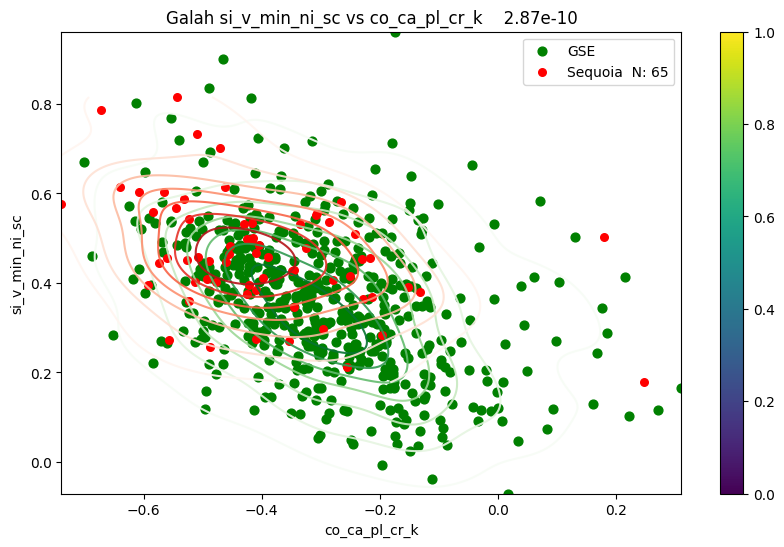

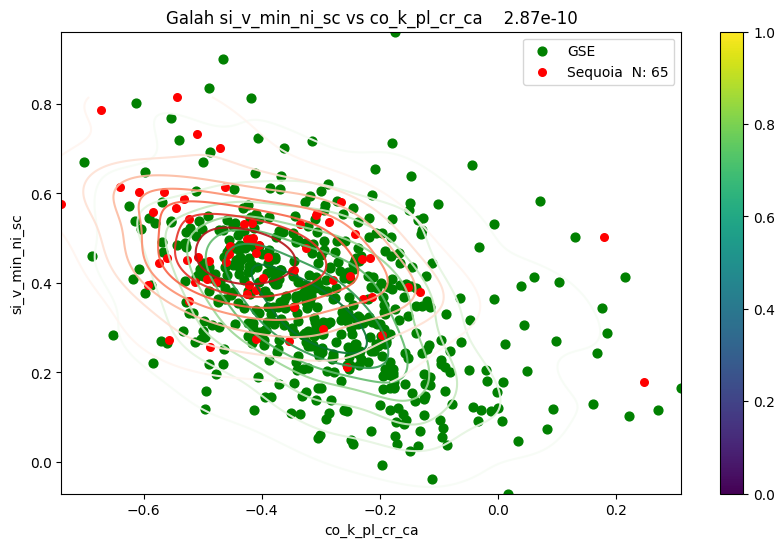

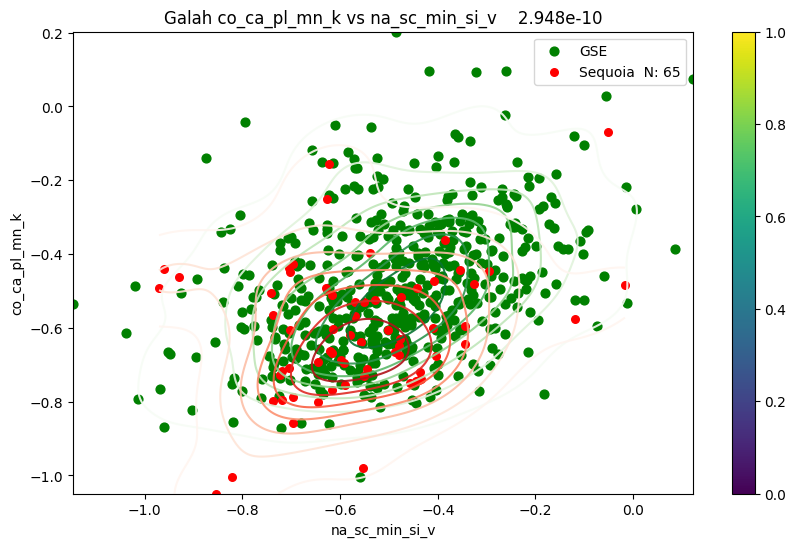

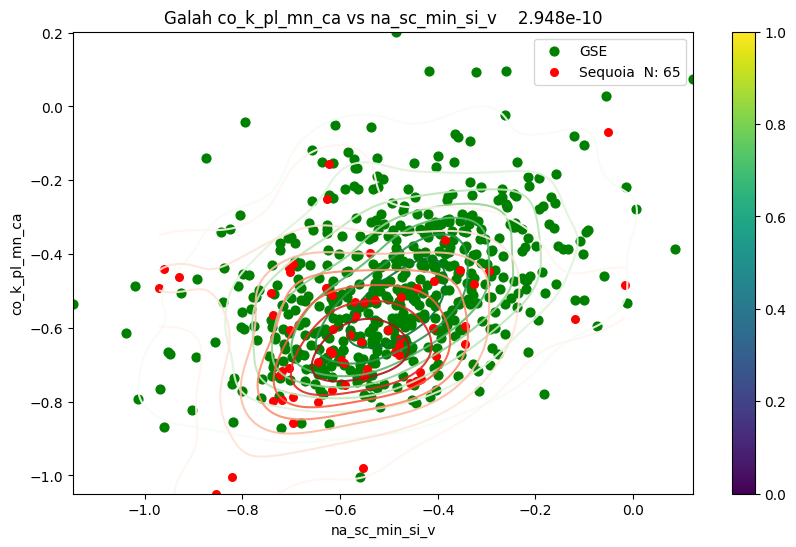

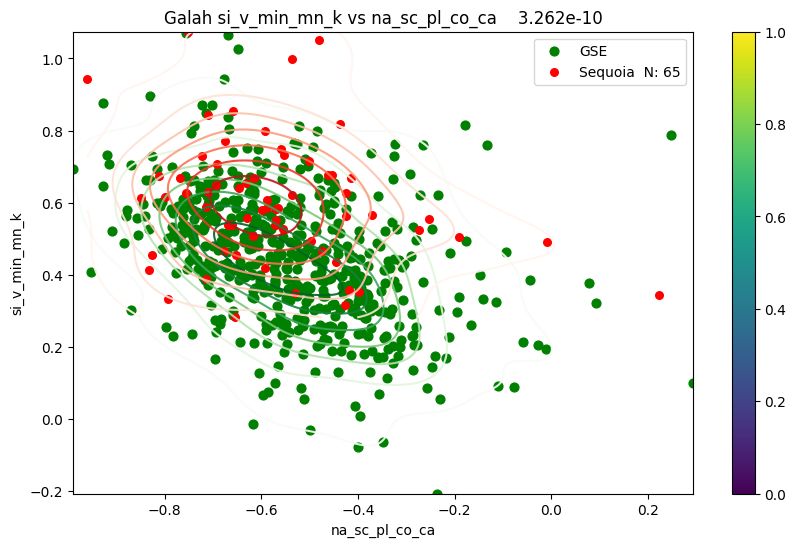

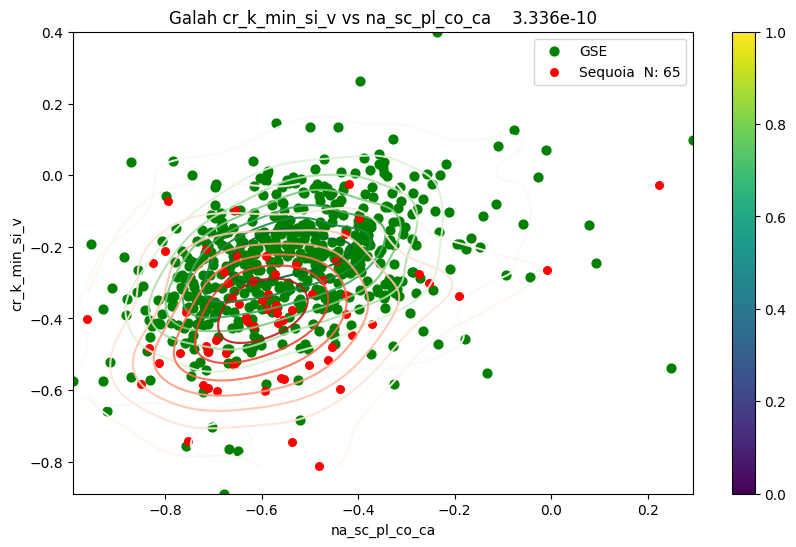

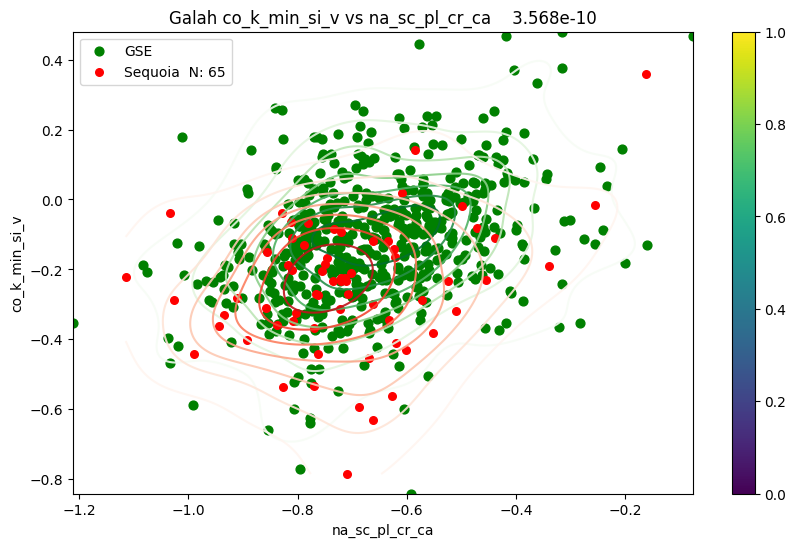

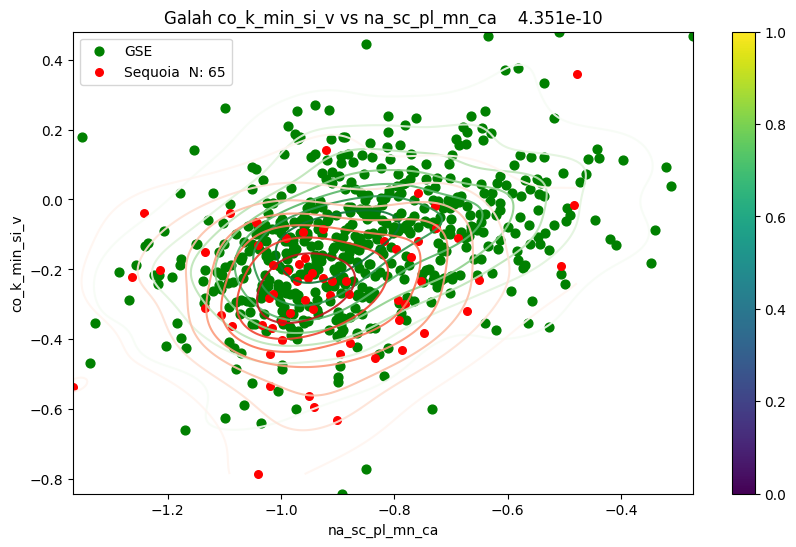

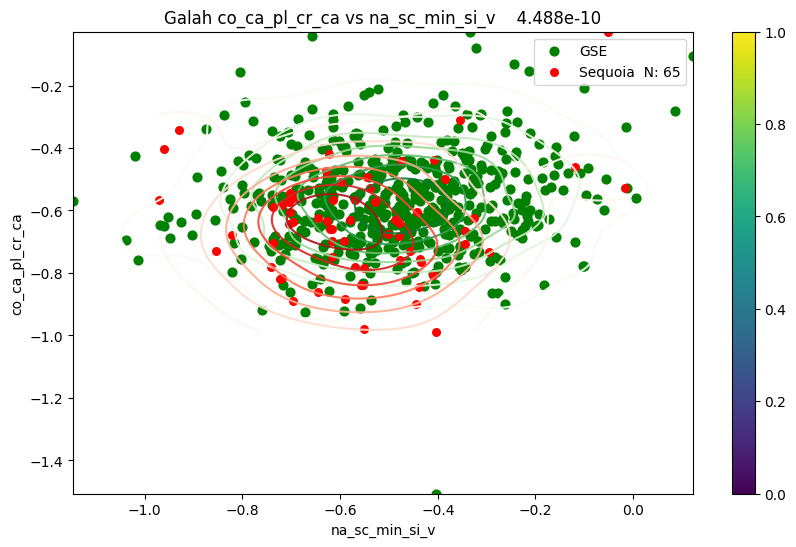

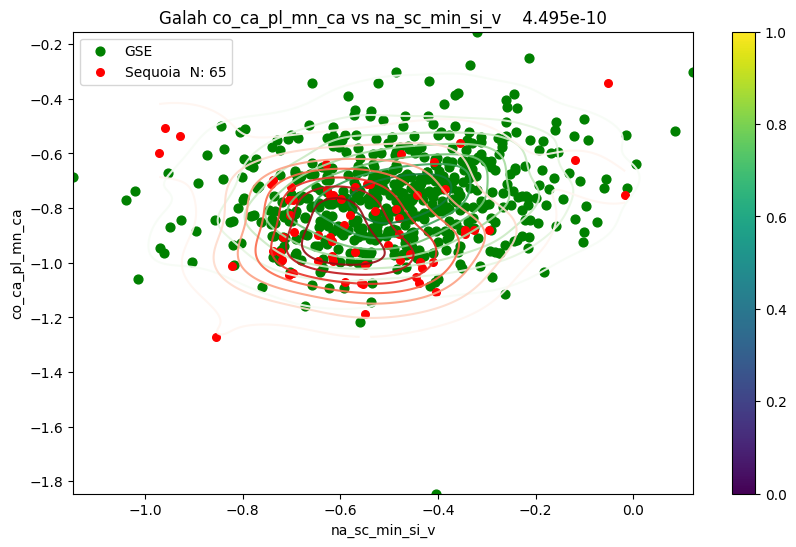

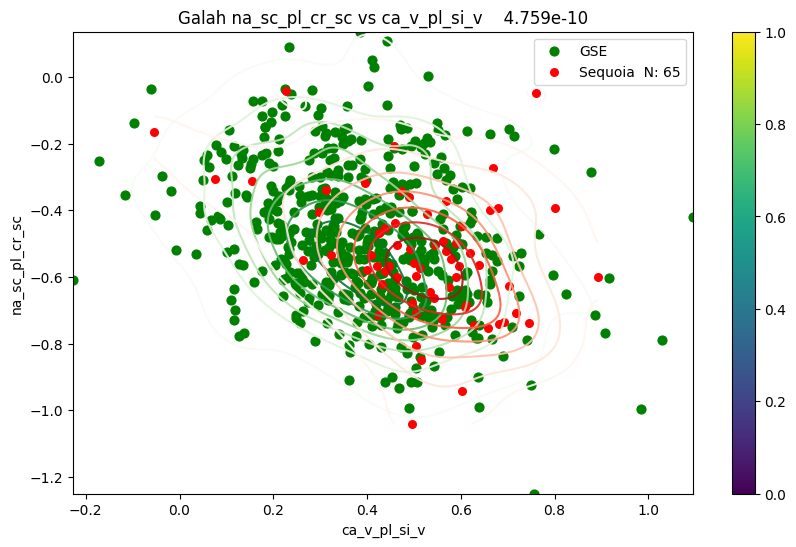

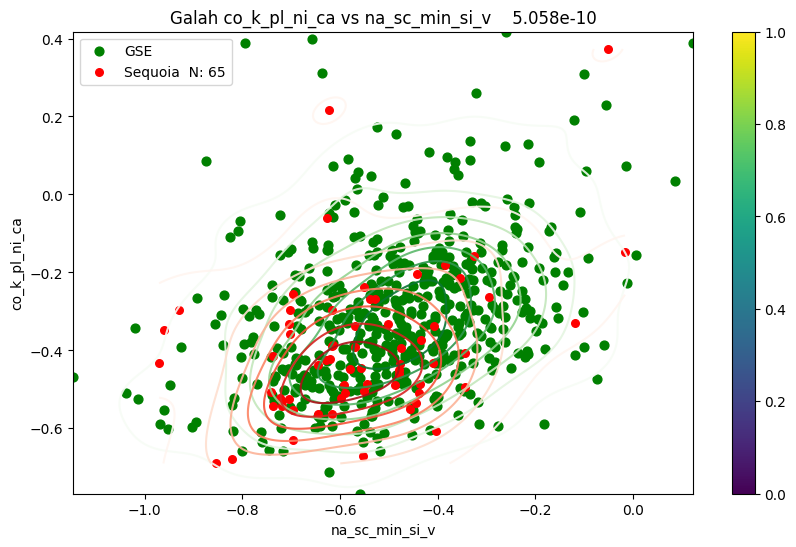

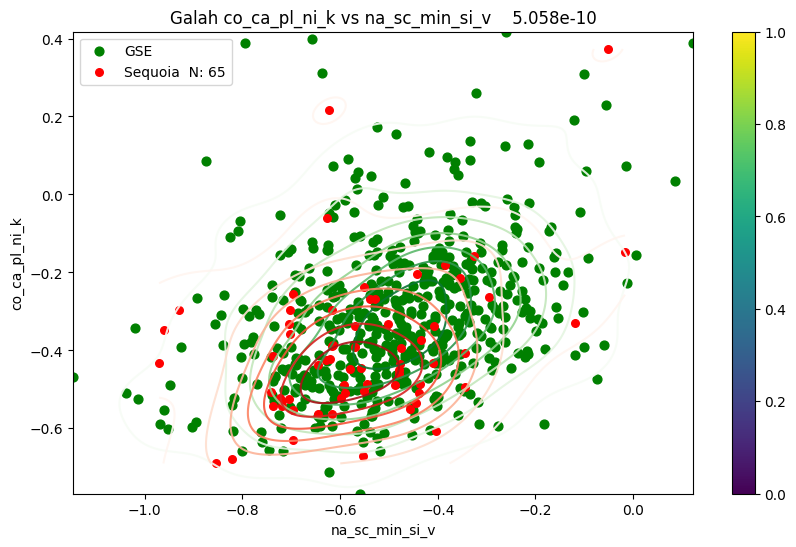

In [59]:
for row in range(0,15):


    ratio_combos_1 = chosen_file['ratio_com_1'][row]
    ratio_combos_2 = chosen_file['ratio_com_2'][row]
    com_P_value = f"{chosen_file['p_value'][row]:.4g}"


    fig,ax = plt.subplots(figsize=(10, 6))

    elm_ratio1 = ratio_combos_1
    elm_ratio2 = ratio_combos_2


    # plt.scatter(galah_Gaia_new_ratios[elm_ratio1], galah_Gaia_new_ratios[elm_ratio2], color = 'grey', label = 'All Galah', s = 0.3, alpha = 0.2)
    # sns.kdeplot(
    #     x=galah_Gaia_new_ratios[elm_ratio1].dropna(),
    #     y=galah_Gaia_new_ratios[elm_ratio2].dropna(),
    #     levels=8,
    #     cmap='Greys',
    #     thresh=0.05,
    #     fill=False,
    #     linewidths=1.5,
    #     cut=0,
    #     alpha=0.9,
    #     ax=ax,
    # )

    # sc  = ax.scatter(Halo_w_combined_ratios[elm_ratio1], Halo_w_combined_ratios[elm_ratio2],
    #             c = (Halo_w_combined_ratios['fe_h']), cmap = 'rainbow',s = 10,
    #             #  color = 'grey', s = 40,
    #              label = 'Halo', alpha = 0.9)
    # sns.kdeplot(
    #     x= Halo_w_combined_ratios[elm_ratio1].dropna(),
    #     y= Halo_w_combined_ratios[elm_ratio2].dropna(),
    #     levels=8,
    #     cmap='cool',
    #     thresh=0.05,
    #     fill=False,
    #     linewidths=1.5,
    #     cut=0,
    #     alpha=0.9,
    #     ax=ax,
    #     label = 'Halo'
    # )

    sc = ax.scatter(GSE_w_combined_ratios[elm_ratio1], GSE_w_combined_ratios[elm_ratio2], 
                    # c = GSE_w_combined_ratios['fe_h'], cmap = 'rainbow',
                    color = 'green', 
                    label = 'GSE', s = 40)
    sns.kdeplot(
        x= GSE_w_combined_ratios[elm_ratio1].dropna(),
        y= GSE_w_combined_ratios[elm_ratio2].dropna(),
        levels=8,
        cmap='Greens',
        thresh=0.05,
        fill=False,
        linewidths=1.5,
        cut=0,
        alpha=0.9,
        ax=ax,
        label = 'GSE'
    )

    num = len(Sequoia_w_combined_ratios)

    sc =ax.scatter(Sequoia_w_combined_ratios[elm_ratio1], Sequoia_w_combined_ratios[elm_ratio2], 
            #    c = Sequoia_w_combined_ratios['fe_h'], cmap = 'rainbow',
               color = 'r', 
               label = f'Sequoia  N: {num}', s = 30)
    sns.kdeplot(
        x=Sequoia_w_combined_ratios[elm_ratio1].dropna(),
        y= Sequoia_w_combined_ratios[elm_ratio2].dropna(),
        levels=8,
        cmap='Reds',
        thresh=0.05,
        fill=False,
        linewidths=1.5,
        cut=0,
        alpha=0.9,
        ax=ax,
        label = 'Sequoia'
    )

    # ax.scatter(v_mean + 0.02, sc_mean - 0.14, color = 'k', s = 40)
    # all_x_values.append(Sequoia_w_combined_ratios[elm_ratio1])
    # all_y_values.append(Sequoia_w_combined_ratios[elm_ratio2])

    ax.set_xlabel(F'{elm_ratio1}')
    ax.set_ylabel(F'{elm_ratio2}')
    leg = ax.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
    ax.legend()
    for handle in leg.legend_handles:
        handle.set_sizes([30])
        ax.set_title(F'Galah {elm_ratio2} vs {elm_ratio1}    {com_P_value}')

    plt.colorbar(sc)

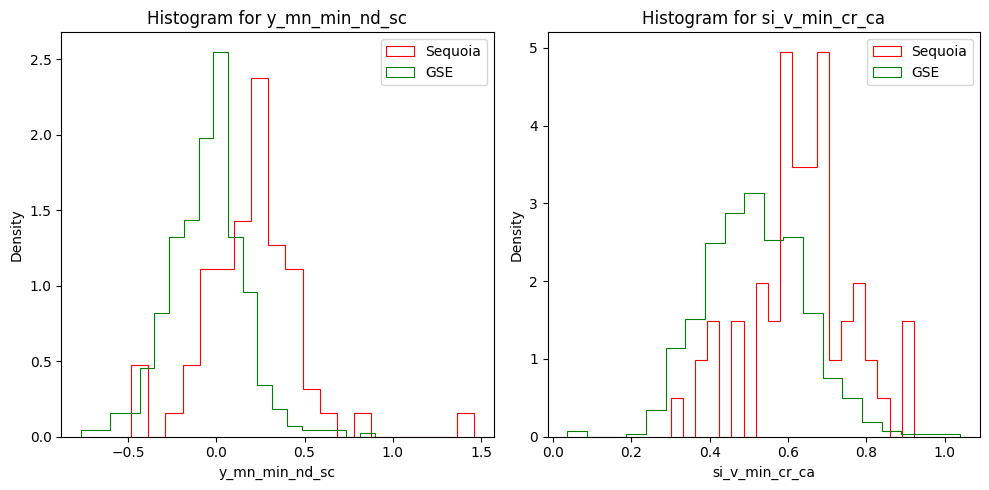

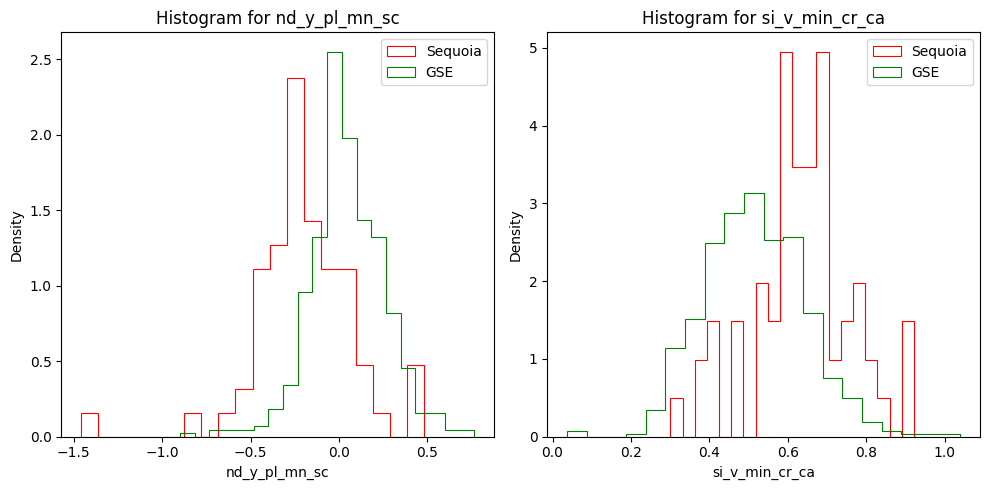

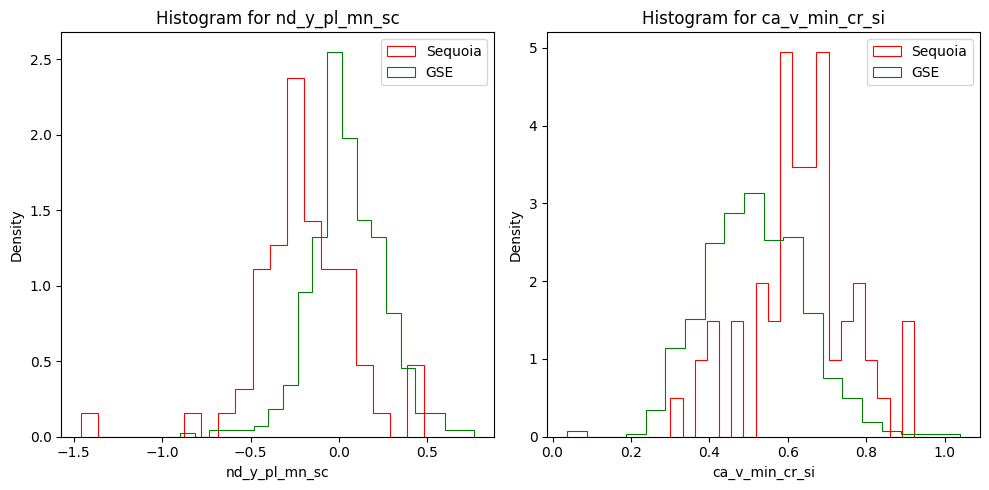

In [88]:
for row in range(0, 3):
    ratio_combos_1 = chosen_file['ratio_com_1'][row]
    ratio_combos_2 = chosen_file['ratio_com_2'][row]

    fig, axes = plt.subplots(1,2, figsize=(10,5), sharex=False)

    

    axes[0].hist(
        Sequoia_w_combined_ratios[ratio_combos_1].dropna(),
        bins=20,
        linewidth=0.8,
        density=True,
        histtype='step',
        label='Sequoia',
        color='r'
    )
    axes[0].hist(
        GSE_w_combined_ratios[ratio_combos_1].dropna(),
        bins=20,
        linewidth=0.8,
        density=True,
        histtype='step',
        label='GSE',
        color='green'
    )
    axes[0].set_xlabel(ratio_combos_1)
    axes[0].set_ylabel('Density')
    axes[0].legend()
    axes[0].set_title(f'Histogram for {ratio_combos_1}')

    axes[1].hist(
        Sequoia_w_combined_ratios[ratio_combos_2].dropna(),
        bins=20,
        linewidth=0.8,
        density=True,
        histtype='step',
        label='Sequoia',
        color='r'
    )
    axes[1].hist(
        GSE_w_combined_ratios[ratio_combos_2].dropna(),
        bins=20,
        linewidth=0.8,
        density=True,
        histtype='step',
        label='GSE',
        color='green'
    )
    axes[1].set_xlabel(ratio_combos_2)
    axes[1].set_ylabel('Density')
    axes[1].legend()
    axes[1].set_title(f'Histogram for {ratio_combos_2}')

    fig.tight_layout()
    plt.show()